In [12]:
import pandas as pd

df = pd.read_csv("/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/data/processed/merged_restaurant_data.csv")

df.head()

,name,city,province,latitude,longitude,state_name,population
0,Wendy's,Washington Court House,OH,39.53255,-83.44526,Ohio,14439
1,Frisch's Big Boy,Maysville,KY,38.62736,-83.79141,Kentucky,8737
2,OMG! Rotisserie,Athens,OH,39.35155,-82.09728,Ohio,23396
3,Domino's Pizza,Hamilton,OH,39.41760,-84.47641,Ohio,63468
4,Domino's Pizza,Englewood,OH,39.86969,-84.29358,Ohio,13356


In [13]:
city_counts = (
    df.groupby(["city", "province", "population"])
      .size()
      .reset_index(name="restaurant_count")
)

In [14]:
small_cities = city_counts[
    (city_counts["population"] >= 10000) &
    (city_counts["population"] <= 100000)
].copy()

In [15]:
small_cities["restaurants_per_10000"] = (
    small_cities["restaurant_count"] /
    small_cities["population"]
) * 10000

In [16]:
top10 = small_cities.sort_values(
    "restaurants_per_10000",
    ascending=False
).head(10)

top10

,city,province,population,restaurant_count,restaurants_per_10000
1860,Mount Airy,NC,10633,12,11.285620
1956,Newport,KY,13967,15,10.739600
635,Covington,LA,11658,9,7.720021
546,Cleveland,MS,10623,8,7.530829
1013,Glasgow,KY,15197,11,7.238271
425,Carroll,IA,10208,7,6.857367
2208,Placerville,CA,10762,7,6.504367
2778,Traverse City,MI,15593,10,6.413134
1723,Meadville,PA,12577,8,6.360817
271,Bloomsburg,PA,13024,8,6.142506


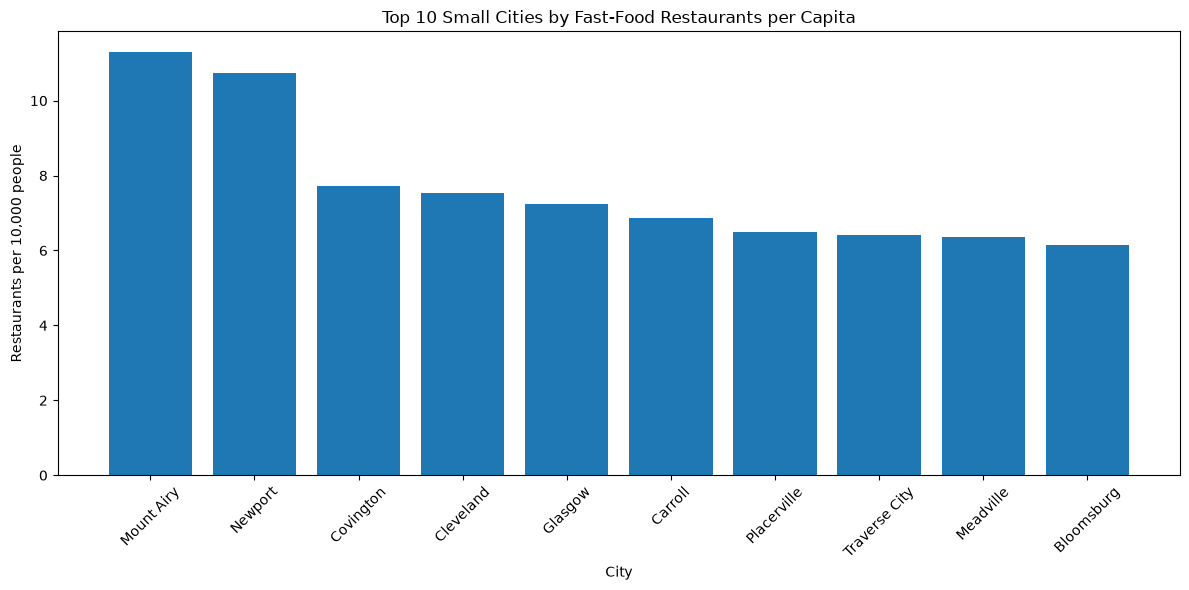

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10["city"],
    top10["restaurants_per_10000"]
)

plt.xticks(rotation=45)
plt.ylabel("Restaurants per 10,000 people")
plt.xlabel("City")
plt.title("Top 10 Small Cities by Fast-Food Restaurants per Capita")

plt.tight_layout()

plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/q6_small_cities_per_capita.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()